# Notebook 2 — Metrische XGBoost-Baseline

**Ziel:** Entwicklung und Evaluation einer metrischen Baseline für die
Unterscheidung von `mali` gegenüber (`anom` + `norm`) auf CloudAnoBench.

**Methodische Kernelemente:**
- Nutzung ausschließlich der 5 universellen Features (`cpu_usage`, `mem_usage`,
  `disk_io`, `net_in`, `net_out`) zur Vermeidung von Schema-Leakage
- Gruppenbasierter `GroupShuffleSplit` (Gruppenkey: `dataset_type + scenario_id`)
- XGBoost-Baseline mit `eval_metric='aucpr'` und `scale_pos_weight`
- Schwellenwertwahl unter der Nebenbedingung `Recall ≥ 0.95`
- Quantifizierung der False-Positive-Rate als Ausgangspunkt für die spätere
  log-basierte Verifikation in Notebook 3

**Input:** Bereinigte Parquet-Artefakte aus Notebook 1  
**Output:** Metrik-Baseline-Ergebnisse, `docs/feature_importance_baseline.png`,
`docs/pr_curve_baseline.png`

In [1]:
import pandas as pd
import os
import numpy as np
from xgboost import (XGBClassifier, plot_importance)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (recall_score, confusion_matrix, precision_recall_curve, average_precision_score, f1_score)
import time
import matplotlib.pyplot as plt

base_path = os.path.join(os.getcwd(), "..", "data")


# Daten laden
processed_path = os.path.join(base_path, "processed")

mali_clean = pd.read_parquet(os.path.join(processed_path, "mali_clean.parquet"))
anom_clean = pd.read_parquet(os.path.join(processed_path, "anom_clean.parquet"))
norm_clean = pd.read_parquet(os.path.join(processed_path, "norm_clean.parquet"))


print(mali_clean.shape, anom_clean.shape, norm_clean.shape)

(19384, 39) (41400, 39) (51208, 39)


In [2]:
# Alle drei kombinieren
all_data = pd.concat([mali_clean, anom_clean, norm_clean], ignore_index=True)

# Eindeutige Gruppen-ID pro Dataset+Szenario (verhindert Leakage cross-dataset)
all_data['group_id'] = all_data['dataset_type'] + '_' + all_data['scenario_id'].astype(str)

# Nur die 5 universellen Features (in allen 3 Datasets vorhanden) — verhindert Schema-Leakage
feature_cols = sorted(['cpu_usage', 'mem_usage', 'disk_io', 'net_in', 'net_out'])

X      = all_data[feature_cols]
y      = all_data['label']
groups = all_data['group_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]
meta_test = all_data[['dataset_type', 'scenario_id']].iloc[test_idx]

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train pos={pos}, neg={neg} → scale_pos_weight: {scale_pos_weight:.2f}")
print(f"Test dataset breakdown:\n{meta_test['dataset_type'].value_counts()}")

Train: (89222, 5) | Test: (22770, 5)
Train pos=15064, neg=74158 → scale_pos_weight: 4.92
Test dataset breakdown:
dataset_type
norm    11610
anom     6840
mali     4320
Name: count, dtype: int64


In [3]:
model = XGBClassifier(
    n_estimators=300,          # Obergrenze; early stopping bestimmt echte Anzahl
    max_depth=6,               # Standard für tabellarische Daten; verhindert Overfitting
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',        # Histogram-basiert — effizienter bei 89k Samples
    eval_metric='aucpr',       # PR-AUC statt logloss: robuster bei 1:4.92-Ungleichgewicht
    early_stopping_rounds=20,  # Stoppt wenn aucpr sich 20 Runden nicht verbessert
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print("Training abgeschlossen.")
print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-aucpr:0.18391
[50]	validation_0-aucpr:0.21533
[100]	validation_0-aucpr:0.22968
[129]	validation_0-aucpr:0.23027
Training abgeschlossen.
Best iteration: 109


Early Stopping wurde auf dem Holdout-Testset überwacht. Da kein separates
Validierungsset existiert und der `GroupShuffleSplit` in dieser Phase nur
einen Train-Test-Split liefert, ist dies eine methodische Limitation:
Die berichteten Testmetriken können dadurch leicht optimistisch ausfallen,
weil das Modell indirekt auf den Testlabels trainiert (Stopp-Zeitpunkt wird
anhand der Testset-Performance bestimmt). Diese Einschränkung ist der
Datenlage geschuldet und wird in der Thesis explizit als bekannte Limitation diskutiert.

In [4]:
t0 = time.time()
y_proba = model.predict_proba(X_test)[:, 1]
latency_ms = (time.time() - t0) * 1000

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

# Höchster Threshold der noch Recall >= 0.95 garantiert
# → konservativste Entscheidungsgrenze, minimiert FPR bei fixiertem Recall
valid_thresholds = thresholds[recalls[:-1] >= 0.95]
best_threshold = float(valid_thresholds.max()) if len(valid_thresholds) > 0 else float(thresholds[0])

y_pred = (y_proba >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

precision_at_t = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"Average Precision (AP):  {ap:.4f}")
print(f"Gewählter Threshold:     {best_threshold:.4f}")
print(f"Recall @ threshold:      {recall_score(y_test, y_pred):.4f}")
print(f"Precision @ threshold:   {precision_at_t:.4f}")
print(f"F1 @ threshold:          {f1_score(y_test, y_pred):.4f}")
print(f"Latenz predict_proba:    {latency_ms:.1f} ms  ({X_test.shape[0]} Samples)")
print(f"FPR gesamt (anom+norm):  {fp / (fp + tn):.4f}  ({fp} FP von {fp+tn})")


Average Precision (AP):  0.2326
Gewählter Threshold:     0.0222
Recall @ threshold:      0.9500
Precision @ threshold:   0.2180
F1 @ threshold:          0.3546
Latenz predict_proba:    63.7 ms  (22770 Samples)
FPR gesamt (anom+norm):  0.7980  (14724 FP von 18450)


In [5]:
# FPR getrennt nach Dataset-Typ: prüft ob Modell zwischen technischen
# Anomalien (anom) und normalen Lastspitzen (norm) unterscheidet.
#
# WICHTIG — Granularität:
# Diese FPR-Werte sind auf ZEILENEBENE berechnet (je Metrik-Zeitreihenpunkt).
# total_sub entspricht der Anzahl der Zeilen pro Typ, nicht der Anzahl der Cases.
# Die Case-Ebene-FPR (1 Entscheidung pro Case, nach Max-Aggregation) wird erst
# im Fusions-Notebook (Notebook 4) berichtet:
#   FPR_anom (Case-Ebene) ≈ 0.24  (18 von 76 Cases)
#   FPR_norm (Case-Ebene) ≈ 0.28  (36 von 129 Cases)
# Diese deutlich niedrigeren Werte sind methodisch nicht direkt mit den
# folgenden Zeilenebene-Werten vergleichbar.
for dtype in ['anom', 'norm']:
    mask = (meta_test['dataset_type'] == dtype).values
    fp_sub = y_pred[mask].sum()
    total_sub = mask.sum()
    print(f"FPR {dtype} (Zeilenebene): {fp_sub / total_sub:.4f}  ({fp_sub} FP von {total_sub} Zeilen)")

FPR anom (Zeilenebene): 0.8042  (5501 FP von 6840 Zeilen)
FPR norm (Zeilenebene): 0.7944  (9223 FP von 11610 Zeilen)


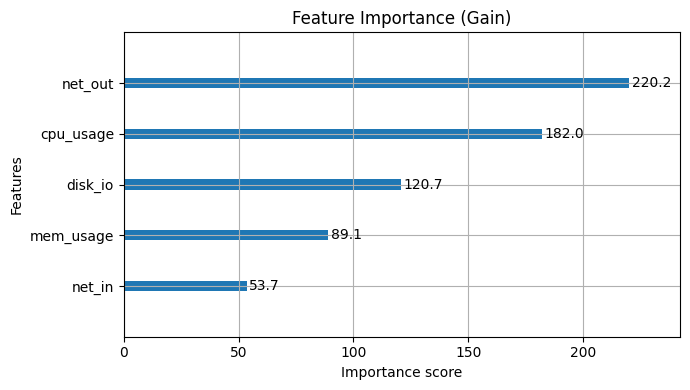

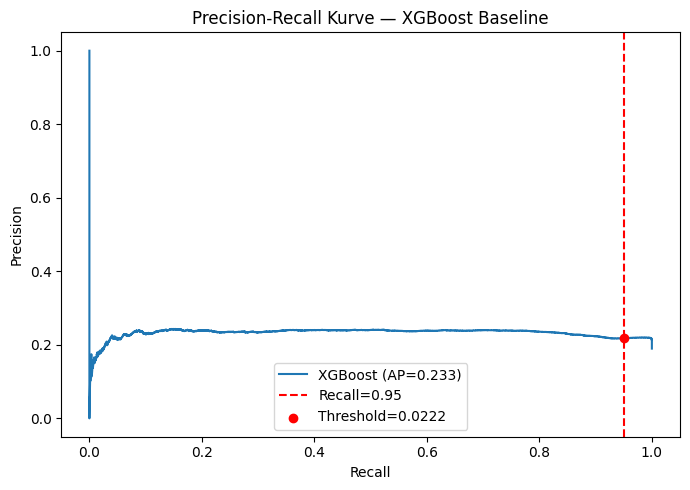

In [6]:
docs_path = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(docs_path, exist_ok=True)

# Feature Importance
fig, ax = plt.subplots(figsize=(7, 4))

# gain: mittlere Verbesserung des Loss pro Split — aussagekräftiger als Splitting-Häufigkeit (weight)
plot_importance(model, ax=ax, importance_type='gain', title='Feature Importance (Gain)', values_format='{v:.1f}')
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "feature_importance_baseline.png"), dpi=150)
plt.show()

# Precision-Recall Kurve
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls, precisions, label=f'XGBoost (AP={ap:.3f})')
ax.axvline(x=0.95, color='red', linestyle='--', label='Recall=0.95')
ax.scatter([recall_score(y_test, y_pred)],
           [tp / (tp + fp) if (tp + fp) > 0 else 0],
           color='red', zorder=5, label=f'Threshold={best_threshold:.4f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Kurve — XGBoost Baseline')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "pr_curve_baseline.png"), dpi=150)
plt.show()

## Ergebnis der metrischen Baseline

| Metrik | Wert |
|---|---|
| Average Precision | 0.2326 |
| Recall @ Threshold | 0.9500 |
| Precision @ Threshold | 0.2180 |
| F1 @ Threshold | 0.3546 |
| FPR (Zeilenebene) | 0.7980 |
| Threshold | 0.0222 |

Die metrische Baseline erfüllt die Recall-Nebenbedingung (≥ 0.95),
weist jedoch eine sehr hohe False-Positive-Rate auf Zeilenebene auf (79.8 %).
Ursache ist der niedrige Threshold (0.0222), der für die Recall-Einhaltung
bei begrenzter Ausdrucksstärke der 5 universellen Features erforderlich ist.

Diese Ausgangslage motiviert **Notebook 3**: Die Log-Dateien werden dort
als zusätzliche Verifikationsschicht auf Case-Ebene eingesetzt,
um Fehlalarme zu reduzieren, ohne den Recall wesentlich zu senken.